# 1. Set up

In [1]:
!pip install pandas
!pip install polars
!pip install scikit-learn
!pip install pyarrow
!pip install torch
!pip install xgboost category_encoders scikit-plot
!pip install pyproj
!pip install tqdm
!pip install hdbscan


# 2. Import necessary libraries

In [2]:
import pandas as pd
import polars as pl
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN
from sklearn.ensemble import IsolationForest

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

from sklearn.model_selection import RepeatedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, precision_recall_curve, precision_score, recall_score, f1_score
from collections import defaultdict

from sklearn.model_selection import train_test_split
import category_encoders as ce
import xgboost as xgb
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score, roc_curve

from xgboost import plot_importance

# 3. Define global variables

In [3]:
INPUT_EVENTOS_FRAUDE_PATH = "../data/inputs/eventos_fraude_al_31_03_2025_v3.csv"
INPUT_EVENTOS_CONTROL_PATH = "../data/inputs/eventos_no_fraude_al_31_03_2025_all.csv"
INPUT_CONSUMOS_FRAUDE_PATH = "../data/inputs/consumos_fraude_al_31_03_2025_v3.csv"
INPUT_CONSUMOS_CONTROL_PATH = "../data/inputs/consumos_no_fraude_al_31_03_2025_all.csv"
INPUT_FRAUDES_PATH = "../data/inputs/fraudes_al_31_03_2025_fecha_fin.csv"

In [4]:
INPUT_EVENTOS_FRAUDE_PATH_ABRIL = "../data/inputs/eventos_fraude_al_30_04_2025_v3.csv"
INPUT_EVENTOS_CONTROL_PATH_ABRIL = "../data/inputs/eventos_no_fraude_al_30_04_2025_all.csv"
INPUT_CONSUMOS_FRAUDE_PATH_ABRIL = "../data/inputs/consumos_fraude_al_30_04_2025_v3.csv"
INPUT_CONSUMOS_CONTROL_PATH_ABRIL = "../data/inputs/consumos_no_fraude_al_30_04_2025_all.csv"
INPUT_FRAUDES_PATH_ABRIL = "../data/inputs/fraudes_al_30_04_2025_fecha_fin.csv"

In [5]:
train_losses = list()
train_losses_eval = list()
target_col = "target"

In [6]:
ufd_orange = "#f26122"
ufd_blue = "#003865"
ufd_gray = "#cccccc"

# 4. Functions

In [7]:
# nn.Module is the baseline of every model in PyTorch
class Autoencoder(nn.Module):
    def __init__(self, input_dim: int):
        # with super() we initialize the object nn.Module
        super().__init__()
        # We define the decoder that goes little by little reducing the dim
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 64), # 64 neurons for the first layer
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(64,32), # 32 neurons for the second layer
            nn.ReLU(),
            nn.Linear(32, 16)
            
        )
        # We define the decoder that goes little by little upgrading the dim. Reconstruction part
        self.decoder = nn.Sequential(
            nn.Linear(16, 32), 
            nn.ReLU(),
            nn.Linear(32, 64),
            nn.ReLU(),
            nn.Linear(64,input_dim)
        )

    def forward(self, x):
        """
        Forward method that defines how the information flows. It just simply applys the encoder-decoder
        architecture.
        """
        z = self.encoder(x)
        return self.decoder(z)

In [8]:
def crear_pivot_detallado(df: pd.DataFrame, 
                          columnas_inspecciones: list,
                          columnas_eventos: list) -> pd.DataFrame:
    """
    Crea un pivot manteniendo toda la información de conteos por combinación et-c
    """
    # Primero, crear una columna que combine et y c para identificar cada tipo de evento
    df_trabajo = df.copy()
    df_trabajo['tipo_evento'] = df_trabajo['et'].astype(str) + '_' + df_trabajo['c'].astype(str)
   
    # Crear el diccionario de agregación base
    agg_dict = {}
   
    # Para las columnas de inspecciones: tomar el primer valor (son iguales para cada grupo)
    for col in columnas_inspecciones:
        agg_dict[col] = 'first'
   
    # Para las columnas de eventos: necesitamos tratamiento especial
    # Las agregaremos después del groupby usando pivot
   
    # Primero hacer el groupby básico para las columnas de inspecciones
    resultado_base = df_trabajo.groupby(['cups_sgc', 'cnt_id']).agg(agg_dict).reset_index()
   
    # Ahora crear el pivot para las columnas de eventos manteniendo la granularidad
    eventos_pivot_list = []
   
    for col_evento in columnas_eventos:
        # Crear un pivot para cada columna de eventos
        pivot_temp = df_trabajo.pivot_table(
            index=['cups_sgc', 'cnt_id'],
            columns='tipo_evento',
            values=col_evento,
            aggfunc='sum',
            fill_value=0
        ).reset_index()
       
        # Renombrar las columnas para incluir el nombre de la columna original
        pivot_temp.columns = ['cups_sgc', 'cnt_id'] + [f"{col_evento}_{col}" for col in pivot_temp.columns[2:]]
       
        eventos_pivot_list.append(pivot_temp)
   
    # Unir todos los pivots de eventos
    resultado_eventos = eventos_pivot_list[0]
    for pivot in eventos_pivot_list[1:]:
        resultado_eventos = resultado_eventos.merge(
            pivot,
            on=['cups_sgc', 'cnt_id'],
            how='outer'
        )
   
    # Unir con el resultado base (inspecciones)
    resultado_final = resultado_base.merge(
        resultado_eventos,
        on=['cups_sgc', 'cnt_id'],
        how='outer'
    )
   
    return resultado_final

In [9]:
def plot_gain(y_true, y_proba):
    data = list(zip(y_true, y_proba))
    data = sorted(data, key=lambda x: x[1], reverse=True)
    y_sorted = np.array([d[0] for d in data])

    cum_gains = np.cumsum(y_sorted) / sum(y_sorted)
    perc_samples = np.arange(1, len(y_sorted)+1) / len(y_sorted)

    plt.figure(figsize=(7,6))
    plt.plot(perc_samples, cum_gains, color=ufd_orange, lw=2, label="Curva de ganancia")
    plt.plot([0,1], [0,1], linestyle="--", color=ufd_gray, label="Modelo aleatorio")

    # Estilo
    plt.grid(alpha=0.3)
    plt.xlabel("% de muestras")
    plt.ylabel("% de positivos acumulados")
    plt.title("Curva de Ganancia", fontsize=14, weight="bold", color=ufd_blue)
    plt.legend()
    plt.show()

In [10]:
def plot_lift(y_true, y_proba, bins=10):
    data = list(zip(y_true, y_proba))
    data = sorted(data, key=lambda x: x[1], reverse=True)
    y_sorted = np.array([d[0] for d in data])

    total_positives_rate = sum(y_sorted) / len(y_sorted)
    group_size = len(y_sorted) // bins
    lift = []

    for i in range(bins):
        start = i * group_size
        end = (i+1) * group_size if i < bins-1 else len(y_sorted)
        group = y_sorted[start:end]
        group_rate = sum(group) / len(group)
        lift.append(group_rate / total_positives_rate)

    # Percentiles crecientes (para graficar normalmente)
    percentiles = list(range(0, 101, int(100/bins)))[1:]  

    plt.figure(figsize=(7,6))
    plt.plot(percentiles, lift, marker="o", color=ufd_blue, lw=2)

    # Etiquetas con valores en cada punto
    for x, val in zip(percentiles, lift):
        plt.text(x, val+0.04, f"{val:.2f}", ha="center", fontsize=8, color=ufd_orange)

    plt.axhline(1, color=ufd_gray, linestyle="--")
    plt.grid(alpha=0.3)
    plt.xlabel("Percentiles")
    plt.ylabel("Lift")
    plt.title("Curva Lift", fontsize=14, weight="bold", color=ufd_blue)

    # Cambiar etiquetas del eje X: 100 → 0
    ticks = plt.xticks()[0]
    new_labels = [str(100 - int(t)) if t >= 0 and t <= 100 else "" for t in ticks]
    plt.xticks(ticks, new_labels)

    plt.show()

In [11]:
def ks_stat(y_true, y_proba):
    fpr, tpr, _ = roc_curve(y_true, y_proba)
    return max(tpr - fpr)

In [12]:
def get_probability_thresholds(y_test, predict_proba_test, cuts):
    """
    Computes the probability thresholds to split the population into groups 
    based on predicted probabilities.

    Example: if cuts = [15, 30], the function will return thresholds that 
    split the population into 3 groups:
        - Top 15% (high risk)
        - Next 15% (medium risk)
        - Remaining 70% (low risk)

    Parameters:
        - y_test: array-like. Ground truth labels (not used for thresholds, 
                  but kept for consistency if later needed).
        - predict_proba_test: list or np.array. Predicted probabilities for the positive class.
        - cuts: list of int. Cumulative percentages that define the split. 
                Values must be between 0 and 100, sorted in ascending order.

    Returns:
        - thresholds: list of float. Probability values that can be used as cut-offs
                      to assign groups.
    """

    # Sort probabilities in descending order
    sorted_proba = np.sort(predict_proba_test)[::-1]
    n = len(sorted_proba)
    
    thresholds = []
    for cut in cuts:
        # index corresponding to the cut (top % of population)
        idx = int(np.ceil(n * (cut/100)))
        # take the probability at that position as threshold
        thresholds.append(float(sorted_proba[idx-1]))  
    
    return thresholds

# 5. Code

## 5.1. Data processing

We will load the data, both the training and the validation data

In [13]:
eventos_fraude = pl.read_csv(INPUT_EVENTOS_FRAUDE_PATH)
eventos_control = pl.read_csv(INPUT_EVENTOS_CONTROL_PATH)
consumos_fraude = pl.read_csv(INPUT_CONSUMOS_FRAUDE_PATH).drop(["tuvo_fraude_previo", "tuvo_fraude_reciente", "estado_fraude"])
consumos_control = pl.read_csv(INPUT_CONSUMOS_CONTROL_PATH).drop(["tuvo_fraude_previo", "tuvo_fraude_reciente", "estado_fraude"])
fraudes = pd.read_csv(INPUT_FRAUDES_PATH).rename(columns={"cups": "cups_sgc", "fraudes_en_90_dias": "target"})

# sólo hay que pivotar la tabla de eventos para después unirla con las de consumos
eventos = pl.concat([eventos_control, eventos_fraude])
consumos = pl.concat([consumos_control, consumos_fraude])

In [14]:
print(len(eventos))
print(len(consumos)) 
print(len(fraudes))

454046
34612
3231


In [15]:
eventos_fraude_abril = pl.read_csv(INPUT_EVENTOS_FRAUDE_PATH_ABRIL)
eventos_control_abril = pl.read_csv(INPUT_EVENTOS_CONTROL_PATH_ABRIL)
consumos_fraude_abril = pl.read_csv(INPUT_CONSUMOS_FRAUDE_PATH_ABRIL).drop(["tuvo_fraude_previo", "tuvo_fraude_reciente", "estado_fraude"])
consumos_control_abril = pl.read_csv(INPUT_CONSUMOS_CONTROL_PATH_ABRIL).drop(["tuvo_fraude_previo", "tuvo_fraude_reciente", "estado_fraude"])
fraudes_abril = pd.read_csv(INPUT_FRAUDES_PATH_ABRIL).rename(columns={"cups": "cups_sgc", "fraudes_en_90_dias": "target"})

# sólo hay que pivotar la tabla de eventos para después unirla con las de consumos
eventos_abril = pl.concat([eventos_control_abril, eventos_fraude_abril])
consumos_abril = pl.concat([consumos_control_abril, consumos_fraude_abril])

In [16]:
# Extraemos las columnas numéricas de la tabla eventos
columnas_eventos = [col for col in eventos.columns if col not in ['cups_sgc', 'cnt_id', 'et', 'c'] and "eventos" in col]
columnas_inspecciones = [col for col in eventos.columns if col not in ['cups_sgc', 'cnt_id', 'et', 'c'] and "inspecciones" in col]

# Debemos rellenar los nulos de las columnas 'c' y 'et' antes de crear 'tipo_evento'
eventos = eventos.with_columns([
    pl.col("c").fill_null("NA").cast(pl.Utf8),
    pl.col("et").fill_null("NA").cast(pl.Utf8)
])
eventos_abril = eventos_abril.with_columns([
    pl.col("c").fill_null("NA").cast(pl.Utf8),
    pl.col("et").fill_null("NA").cast(pl.Utf8)
])

# Creación de la columna tipo_evento
eventos = eventos.with_columns(
    (pl.col("et") + "_" + pl.col("c")).alias("tipo_evento")
)
eventos_abril = eventos_abril.with_columns(
    (pl.col("et") + "_" + pl.col("c")).alias("tipo_evento")
)

Convertimos los polars data frames a pandas df:

In [17]:
eventos_df_pandas = eventos.to_pandas()
consumos_pandas = consumos.to_pandas()

eventos_df_pandas_abril = eventos_abril.to_pandas()
consumos_pandas_abril = consumos_abril.to_pandas()

Vamos a pivotar la tabla de eventos para tener un único valor de cups por cada fila:

In [18]:
# Ejecutar la función
print("Creando pivot detallado...")
eventos_pivotado_detallado = crear_pivot_detallado(eventos_df_pandas, columnas_inspecciones, columnas_eventos)
eventos_pivotado_detallado_abril = crear_pivot_detallado(eventos_df_pandas_abril, columnas_inspecciones, columnas_eventos)

Creando pivot detallado...


In [19]:
final_df = eventos_pivotado_detallado.merge(
    consumos.to_pandas(), on=["cups_sgc", "cnt_id"], how="outer"
).merge(fraudes, on=["cups_sgc"], how="left")

final_df.drop_duplicates(inplace=True)

final_df.head(10)

,cups_sgc,cnt_id,cnt_inspecciones_semana_actual,cnt_inspecciones_semana_pasada,cnt_inspecciones_misma_semana_anio_pasado,cnt_inspecciones_mes_actual,cnt_inspecciones_mes_pasado,cnt_inspecciones_mismo_mes_anio_pasado,cnt_inspecciones_trimestre_actual,cnt_inspecciones_trimestre_pasado,...,porcentaje_calidad_datos_trimestre_actual_incorrectos,porcentaje_calidad_datos_trimestre_pasado_correctos,porcentaje_calidad_datos_trimestre_pasado_incorrectos,porcentaje_calidad_datos_mismo_trimestre_anio_pasado_correctos,porcentaje_calidad_datos_mismo_trimestre_anio_pasado_incorrectos,porcentaje_calidad_datos_anio_actual_correctos,porcentaje_calidad_datos_anio_actual_incorrectos,porcentaje_calidad_datos_anio_anterior_correctos,porcentaje_calidad_datos_anio_anterior_incorrectos,target
0,ES0022000001000008QR1P,SAG0185769835,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.00,91.30,0.00,97.76,0.00,97.52,0.00,99.44,0.00,1.0
1,ES0022000001001149LS1P,SAG0185746454,0.0,0.0,0.0,0.0,28.0,0.0,28.0,0.0,...,0.00,91.30,0.00,97.76,0.00,95.81,0.03,75.35,0.01,NaN
2,ES0022000001001381YV1P,SAG0186400186,0.0,0.0,0.0,0.0,0.0,27.0,0.0,0.0,...,0.09,92.21,0.18,91.99,0.27,98.46,0.16,83.86,0.27,NaN
3,ES0022000001001663LT1P,ZIV0036507981,0.0,0.0,0.0,0.0,0.0,31.0,0.0,54.0,...,0.09,2.17,0.00,0.00,0.00,19.97,0.02,0.00,0.00,NaN
4,ES0022000001002279EH1P,ZIV0047987967,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.00,93.48,0.00,102.06,0.09,99.71,0.00,101.61,0.02,NaN
5,ES0022000001002372AL1P,SAG0185734056,0.0,0.0,0.0,0.0,29.0,0.0,29.0,0.0,...,0.00,78.26,0.00,98.86,0.00,91.50,0.02,99.72,0.00,NaN
6,ES0022000001005251ZT1P,SAG0185729235,0.0,0.0,0.0,0.0,0.0,0.0,0.0,26.0,...,0.00,90.99,0.27,104.35,0.00,98.21,0.09,94.80,0.00,NaN
7,ES0022000001005425KJ1P,SAG0185748781,0.0,0.0,0.0,0.0,0.0,0.0,0.0,28.0,...,0.00,90.17,0.00,95.56,0.00,98.06,0.00,99.70,0.00,NaN
8,ES0022000001006539RT1P,ZIV0050276191,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.00,0.00,0.00,0.00,0.00,1.53,0.03,0.00,0.00,NaN
9,ES0022000001007458VE1P,SAG0185748789,0.0,0.0,0.0,0.0,0.0,0.0,29.0,26.0,...,0.00,89.13,0.00,93.36,0.00,97.15,0.00,98.35,0.00,NaN


In [20]:
final_df_eval = eventos_pivotado_detallado_abril.merge(
    consumos_abril.to_pandas(), on=["cups_sgc", "cnt_id"], how="outer"
).merge(fraudes_abril, on=["cups_sgc"], how="left")

final_df_eval.drop_duplicates(inplace=True)

final_df_eval.head(10)

,cups_sgc,cnt_id,cnt_inspecciones_semana_actual,cnt_inspecciones_semana_pasada,cnt_inspecciones_misma_semana_anio_pasado,cnt_inspecciones_mes_actual,cnt_inspecciones_mes_pasado,cnt_inspecciones_mismo_mes_anio_pasado,cnt_inspecciones_trimestre_actual,cnt_inspecciones_trimestre_pasado,...,porcentaje_calidad_datos_trimestre_actual_incorrectos,porcentaje_calidad_datos_trimestre_pasado_correctos,porcentaje_calidad_datos_trimestre_pasado_incorrectos,porcentaje_calidad_datos_mismo_trimestre_anio_pasado_correctos,porcentaje_calidad_datos_mismo_trimestre_anio_pasado_incorrectos,porcentaje_calidad_datos_anio_actual_correctos,porcentaje_calidad_datos_anio_actual_incorrectos,porcentaje_calidad_datos_anio_anterior_correctos,porcentaje_calidad_datos_anio_anterior_incorrectos,target
0,ES0022000001001149LS1P,SAG0185746454,0.0,0.0,0.0,0.0,0.0,0.0,0.0,28.0,...,0.28,97.78,0.00,100.00,0.00,95.35,0.06,75.35,0.01,NaN
1,ES0022000001001381YV1P,SAG0186400186,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.69,105.42,0.09,93.06,0.28,98.80,0.19,86.59,0.27,NaN
2,ES0022000001001663LT1P,ZIV0036507981,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.56,78.75,0.09,0.00,0.00,28.03,0.07,0.00,0.00,NaN
3,ES0022000001002279EH1P,ZIV0047987967,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.28,105.51,0.00,100.00,0.00,99.46,0.02,101.61,0.02,NaN
4,ES0022000001002372AL1P,SAG0185734056,0.0,0.0,0.0,0.0,0.0,0.0,0.0,29.0,...,0.28,90.05,0.00,96.67,0.00,86.10,0.05,99.44,0.00,NaN
5,ES0022000001005251ZT1P,SAG0185729235,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.28,112.18,0.00,100.00,0.00,98.01,0.11,94.80,0.00,NaN
6,ES0022000001005425KJ1P,SAG0185748781,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.28,105.51,0.00,96.67,0.00,97.88,0.02,99.43,0.00,NaN
7,ES0022000001006539RT1P,ZIV0050276191,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.00,0.00,0.00,0.00,0.00,1.53,0.03,0.00,0.00,NaN
8,ES0022000001007458VE1P,SAG0185748789,0.0,0.0,0.0,0.0,0.0,0.0,0.0,29.0,...,0.28,101.76,0.00,100.00,0.00,96.97,0.02,98.35,0.00,NaN
9,ES0022000001008220MW1P,SOG0100030751,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.00,0.23,0.00,0.00,0.14,8.58,1.37,8.55,0.31,NaN


### 5.1.2. Constant columns

We will delete those columns that have a unique value, thus, constant columns

In [21]:
constant_cols = []

for col in final_df.columns:
    if final_df[col].nunique() == 1 and col not in ['cups_sgc', 'cnt_id', target_col]:
        constant_cols.append(col)
        
        
final_df.drop(columns=constant_cols, inplace=True)

In [22]:
constant_cols_eval = []

for col in final_df_eval.columns:
    if final_df_eval[col].nunique() == 1 and col not in ['cups_sgc', 'cnt_id', target_col]:
        constant_cols.append(col)
        
        
final_df_eval.drop(columns=constant_cols_eval, inplace=True)

### 5.1.3. Duplicated rows

Are there any duplicated rows in the data?

In [23]:
final_df[[col for col in final_df if col not in ['cups_sgc', 'cnt_id']]].duplicated().sum()

np.int64(10)

We observe that there are some little duplicated rows, we are going to delete them

In [24]:
final_df = final_df[~final_df[[col for col in final_df if col not in ['cups_sgc', 'cnt_id']]].duplicated()]

final_df_eval = final_df_eval[~final_df_eval[[col for col in final_df_eval if col not in ['cups_sgc', 'cnt_id']]].duplicated()]

In [25]:
final_df.head(5)

,cups_sgc,cnt_id,cnt_inspecciones_semana_actual,cnt_inspecciones_semana_pasada,cnt_inspecciones_misma_semana_anio_pasado,cnt_inspecciones_mes_actual,cnt_inspecciones_mes_pasado,cnt_inspecciones_mismo_mes_anio_pasado,cnt_inspecciones_trimestre_actual,cnt_inspecciones_trimestre_pasado,...,porcentaje_calidad_datos_trimestre_actual_incorrectos,porcentaje_calidad_datos_trimestre_pasado_correctos,porcentaje_calidad_datos_trimestre_pasado_incorrectos,porcentaje_calidad_datos_mismo_trimestre_anio_pasado_correctos,porcentaje_calidad_datos_mismo_trimestre_anio_pasado_incorrectos,porcentaje_calidad_datos_anio_actual_correctos,porcentaje_calidad_datos_anio_actual_incorrectos,porcentaje_calidad_datos_anio_anterior_correctos,porcentaje_calidad_datos_anio_anterior_incorrectos,target
0,ES0022000001000008QR1P,SAG0185769835,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.00,91.30,0.00,97.76,0.00,97.52,0.00,99.44,0.00,1.0
1,ES0022000001001149LS1P,SAG0185746454,0.0,0.0,0.0,0.0,28.0,0.0,28.0,0.0,...,0.00,91.30,0.00,97.76,0.00,95.81,0.03,75.35,0.01,NaN
2,ES0022000001001381YV1P,SAG0186400186,0.0,0.0,0.0,0.0,0.0,27.0,0.0,0.0,...,0.09,92.21,0.18,91.99,0.27,98.46,0.16,83.86,0.27,NaN
3,ES0022000001001663LT1P,ZIV0036507981,0.0,0.0,0.0,0.0,0.0,31.0,0.0,54.0,...,0.09,2.17,0.00,0.00,0.00,19.97,0.02,0.00,0.00,NaN
4,ES0022000001002279EH1P,ZIV0047987967,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.00,93.48,0.00,102.06,0.09,99.71,0.00,101.61,0.02,NaN


### 5.1.3. Variables selection

In [26]:
# final_df.drop(columns=[col for col in final_df.columns if "porcentaje" in col], inplace=True)
# final_df.drop(columns=[col for col in final_df.columns if "consumo_zero" in col], inplace=True)

We extract the categorical and continuous columns as well as we define the X and y sets

In [27]:
cat_cols = final_df.select_dtypes(include=['object', 'category']).columns.tolist()
cat_cols = [col for col in cat_cols if col not in ['cups_sgc', 'cnt_id', target_col]]

X = final_df.drop(columns=[target_col, 'cups_sgc', 'cnt_id'], errors='ignore')
y = final_df[target_col]

X_eval = final_df_eval.drop(columns=[target_col, 'cups_sgc', 'cnt_id'], errors='ignore')
y_eval = final_df_eval[target_col]

In [28]:
X = X.apply(pd.to_numeric, errors='coerce')

# Opción 1: rellenar NaN con 0
X = X.replace([np.inf, -np.inf], np.nan)
X = X.fillna(0)

# Clip very large/small values to avoid dtype errors
X = X.clip(lower=-1e6, upper=1e6)

X.head(5)

,cnt_inspecciones_semana_actual,cnt_inspecciones_semana_pasada,cnt_inspecciones_misma_semana_anio_pasado,cnt_inspecciones_mes_actual,cnt_inspecciones_mes_pasado,cnt_inspecciones_mismo_mes_anio_pasado,cnt_inspecciones_trimestre_actual,cnt_inspecciones_trimestre_pasado,cnt_inspecciones_mismo_trimestre_anio_pasado,cnt_inspecciones_anio_actual,...,porcentaje_calidad_datos_trimestre_actual_correctos,porcentaje_calidad_datos_trimestre_actual_incorrectos,porcentaje_calidad_datos_trimestre_pasado_correctos,porcentaje_calidad_datos_trimestre_pasado_incorrectos,porcentaje_calidad_datos_mismo_trimestre_anio_pasado_correctos,porcentaje_calidad_datos_mismo_trimestre_anio_pasado_incorrectos,porcentaje_calidad_datos_anio_actual_correctos,porcentaje_calidad_datos_anio_actual_incorrectos,porcentaje_calidad_datos_anio_anterior_correctos,porcentaje_calidad_datos_anio_anterior_incorrectos
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,98.84,0.00,91.30,0.00,97.76,0.00,97.52,0.00,99.44,0.00
1,0.0,0.0,0.0,0.0,28.0,0.0,28.0,0.0,0.0,84.0,...,97.78,0.00,91.30,0.00,97.76,0.00,95.81,0.03,75.35,0.01
2,0.0,0.0,0.0,0.0,0.0,27.0,0.0,0.0,55.0,28.0,...,105.42,0.09,92.21,0.18,91.99,0.27,98.46,0.16,83.86,0.27
3,0.0,0.0,0.0,0.0,0.0,31.0,0.0,54.0,86.0,54.0,...,78.75,0.09,2.17,0.00,0.00,0.00,19.97,0.02,0.00,0.00
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,28.0,...,105.51,0.00,93.48,0.00,102.06,0.09,99.71,0.00,101.61,0.02


In [29]:
X_eval = X_eval.apply(pd.to_numeric, errors='coerce')

# Opción 1: rellenar NaN con 0
X_eval = X_eval.replace([np.inf, -np.inf], np.nan)
X_eval = X_eval.fillna(0)

# Clip very large/small values to avoid dtype errors
X_eval = X_eval.clip(lower=-1e6, upper=1e6)

## 5.2. Parte no supervisada

In [30]:
modelo_rf = RandomForestClassifier(n_estimators=50, max_depth=5, random_state=42)

# Configura la validación cruzada.
# RepeatedKFold es una excelente opción.
# n_splits=5 divide tus datos en 5 "folds" o subconjuntos.
# n_repeats=2 repite todo el proceso 2 veces, lo que te da un total de 10 modelos
# y un ranking de importancia muy robusto.
cv = RepeatedKFold(n_splits=5, n_repeats=2, random_state=42)

# Un diccionario para guardar las importancias de cada columna
importances = defaultdict(list)

y.fillna(0, inplace=True)

# Bucle sobre los splits de validación cruzada
for train_index, val_index in cv.split(X, y):
    X_train_fold, X_val_fold = X.iloc[train_index], X.iloc[val_index]
    y_train_fold, y_val_fold = y.iloc[train_index], y.iloc[val_index]

    # Entrena el modelo en el subconjunto de entrenamiento
    modelo_rf.fit(X_train_fold, y_train_fold)

    # Guarda las importancias de las características
    for i, col in enumerate(X.columns):
        importances[col].append(modelo_rf.feature_importances_[i])

# Calcular la media de las importancias para cada columna
feature_importances_mean = {col: np.mean(imps) for col, imps in importances.items()}

# Convertir a una Serie de pandas para ordenar fácilmente
importances_series = pd.Series(feature_importances_mean).sort_values(ascending=False)

# Seleccionar las 100 mejores características
top_100_features = importances_series.head(70).index.tolist()

# Ahora puedes crear un nuevo DataFrame solo con esas columnas
X_top_100 = X[top_100_features]

In [31]:
X = X[top_100_features]

In [32]:
top_100_features

['consumo_zero_anio_actual',
 'consumo_zero_trimestre_actual',
 'consumo_zero_trimestre_pasado',
 'consumo_zero_trimestre_anio_pasado',
 'porcentaje_calidad_datos_mes_actual_correctos',
 'consumo_zero_anio_anterior',
 'consumo_zero_semana_actual',
 'consumo_zero_mes_actual',
 'consumo_zero_mes_anio_pasado',
 'consumo_min_anio_actual',
 'consumo_zero_semana_pasada',
 'porcentaje_calidad_datos_semana_actual_correctos',
 'porcentaje_calidad_datos_trimestre_actual_correctos',
 'consumo_min_anio_anterior',
 'consumo_count_anio_actual',
 'consumo_zero_mes_pasado',
 'pct_change_semana_actual_vs_pasada',
 'porcentaje_calidad_datos_mes_pasado_correctos',
 'porcentaje_calidad_datos_trimestre_pasado_correctos',
 'porcentaje_calidad_datos_semana_pasada_correctos',
 'porcentaje_calidad_datos_anio_actual_correctos',
 'porcentaje_calidad_datos_misma_semana_anio_pasado_correctos',
 'consumo_count_anio_anterior',
 'consumo_min_trimestre_actual',
 'consumo_zero_semana_anio_pasado',
 'porcentaje_calidad_

In [33]:
cat_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()
cat_cols = [col for col in cat_cols if col not in ['cups_sgc', 'cnt_id', target_col]]

In order to do the no supervised part, we need to scale the data since we are going to use distances within the models

In [34]:
scaler = StandardScaler()
# Ahora escalar
X_scaled = scaler.fit_transform(X)

scaler_eval = StandardScaler()
# Ahora escalar
X_scaled_eval = scaler_eval.fit_transform(X_eval)

### 5.2.1. Modelling

#### DBSCAN cluster

First of all we will use the DBSCAN model. This algorithm is a cluster algorithm based on density. Groups the data that have sufficient neighbors and everything that does not go into a cluster is labeled as -1. Thus, the idea is no more than finiding outliers in the data points.

In [35]:
# import hdbscan
# # Seteamos un radio de 3 alrededor de cada punto y un mínimo de 100 puntos requeridos dentro del vecindario para que un punto sea considerado un punto "core".
# hdb = hdbscan.HDBSCAN(cluster_selection_epsilon=3, min_samples=100).fit(X_scaled)

# cluster_labels = hdb.fit_predict(X_scaled)
# probabilities = hdb.probabilities_


# # Añadir al dataframe
# final_df["hdbscan_labels"] = cluster_labels
# final_df["hdbscan_probabilities"] = probabilities
# final_df["anomaly_dbscan"] = cluster_labels == -1

# print("Estadísticas de HDBSCAN:")
# print(f"Número de clusters: {len(set(cluster_labels)) - (1 if -1 in cluster_labels else 0)}")
# print(f"Outliers: {sum(cluster_labels == -1)}")
# print(f"Probabilidad media: {probabilities.mean():.3f}")

In [36]:
# final_df[final_df["anomaly_dbscan"] == 1]["hdbscan_probabilities"].unique()

In [37]:
# final_df["hdbscan_labels"].unique()

In [38]:
# final_df[final_df["hdbscan_labels"] == 0]["hdbscan_probabilities"].unique()

In [39]:
# Seteamos un radio de 3 alrededor de cada punto y un mínimo de 100 puntos requeridos dentro del vecindario para que un punto sea considerado un punto "core".
# db = DBSCAN(eps=3, min_samples=100).fit(X_scaled)
# # Identificamos outliers haciendo uso de la etiqueta -1
# final_df["anomaly_dbscan"] = db.labels_ == -1

In [40]:
# final_df["anomaly_dbscan"].value_counts()

In [41]:
# Seteamos un radio de 3 alrededor de cada punto y un mínimo de 100 puntos requeridos dentro del vecindario para que un punto sea considerado un punto "core".
db_eval = DBSCAN(eps=3, min_samples=100).fit(X_scaled_eval)
# Identificamos outliers haciendo uso de la etiqueta -1
final_df_eval["anomaly_dbscan"] = db_eval.labels_ == -1

In [42]:
final_df_eval["anomaly_dbscan"].value_counts()

anomaly_dbscan
True     33275
False     3025
Name: count, dtype: int64

#### Isolation forest

Isolation forest es un modelo que trata de aislar los puntos de datos. Devuelve un -1 como un outlier y 1 como un punto "normal".

Isolation forest is a model that tries to aisle data points. It returns a -1 as an outlier and a 1 as a normal point. Thus, if we consider that a CUPS has a -1 prediction, it indicates that its metrics are far away from the general distribution.

In [51]:
from sklearn.preprocessing import MinMaxScaler

iso = IsolationForest(contamination=0.01, random_state=42)
preds = iso.fit_predict(X_scaled)

anomaly_scores = iso.decision_function(X_scaled)

scaler_scores = MinMaxScaler()
probabilities = scaler_scores.fit_transform(anomaly_scores.reshape(-1, 1)).flatten()

# Añadir al dataframe
final_df["iso_anomaly_scores"] = anomaly_scores
final_df["iso_probabilities"] = probabilities
final_df["anomaly_iso"] = preds == -1


print("Información de Isolation Forest:")
print(f"Rango de scores: {anomaly_scores.min():.3f} a {anomaly_scores.max():.3f}")
print(f"Rango de probabilidades: {probabilities.min():.3f} a {probabilities.max():.3f}")
print(f"Outliers detectados: {sum(preds == -1)}")

Información de Isolation Forest:
Rango de scores: -0.151 a 0.286
Rango de probabilidades: 0.000 a 1.000
Outliers detectados: 350


In [58]:
print(f"Score anomalía - min: {final_df[final_df["anomaly_iso"] == 1]["iso_anomaly_scores"].min()}, max: {final_df[final_df["anomaly_iso"] == 1]["iso_anomaly_scores"].max()}")

Score anomalía - min: -0.15143615100774022, max: -5.870438278821055e-06


In [59]:
print(f"Score anomalía - min: {final_df[final_df["anomaly_iso"] == 0]["iso_anomaly_scores"].min()}, max: {final_df[final_df["anomaly_iso"] == 0]["iso_anomaly_scores"].max()}")

Score anomalía - min: 1.8589721216377697e-05, max: 0.28639665202932474


In [50]:
anomaly_scores = iso.decision_function(X_scaled)

print(f"Rango de scores: {anomaly_scores.min():.3f} a {anomaly_scores.max():.3f}")


Rango de scores: -0.151 a 0.286


In [44]:
iso_eval = IsolationForest(contamination=0.01, random_state=42)
preds_eval = iso_eval.fit_predict(X_scaled_eval)
final_df_eval["anomaly_iso"] = preds_eval == -1

In [48]:
np.unique(preds)

array([-1,  1])

#### Autoencoders

Now we are going to go with the approach of autoencoders. The idea here is to find big errors when the decoder tries to reconstruct the input. Then we will find anomalies within the magnitude of that error

In [44]:
X_tensor = torch.tensor(X_scaled, dtype=torch.float32)

# We create a PyTorch dataset that can be consumed by a DataLoader. TensorDataset is a way of evolving tensors
# as a simple dataset
train_data = TensorDataset(X_tensor)
# We create a data loader that divides the dataset in batches of 256 and shuffles the arrange randomly
loader = DataLoader(train_data, batch_size=256, shuffle=True)

In [45]:
model = Autoencoder(input_dim=X_tensor.shape[1])
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

In [46]:
model.train()

Autoencoder(
  (encoder): Sequential(
    (0): Linear(in_features=70, out_features=64, bias=True)
    (1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.2, inplace=False)
    (4): Linear(in_features=64, out_features=32, bias=True)
    (5): ReLU()
    (6): Linear(in_features=32, out_features=16, bias=True)
  )
  (decoder): Sequential(
    (0): Linear(in_features=16, out_features=32, bias=True)
    (1): ReLU()
    (2): Linear(in_features=32, out_features=64, bias=True)
    (3): ReLU()
    (4): Linear(in_features=64, out_features=70, bias=True)
  )
)

In [47]:
for epoch in range(60):
    model.train()
    running_loss = 0
    for batch in loader:
        # we take the batch[0] because TensorDataset only has one input tensor (without target)
        inputs = batch[0]
        outputs = model(inputs)
        loss = criterion(outputs, inputs)
        # we clear the gradients
        optimizer.zero_grad()
        # we calculate the gradients
        loss.backward()
        # we update the weights
        optimizer.step()
        running_loss += loss.item()

    train_losses.append(running_loss / len(loader))

    # Validation
    model.eval()

    print(f"Epoch {epoch+1:02d} | Train Loss: {train_losses[-1]:.4f}")

Epoch 01 | Train Loss: 0.5495
Epoch 02 | Train Loss: 0.3132
Epoch 03 | Train Loss: 0.2449
Epoch 04 | Train Loss: 0.2075
Epoch 05 | Train Loss: 0.1998
Epoch 06 | Train Loss: 0.1909
Epoch 07 | Train Loss: 0.1856
Epoch 08 | Train Loss: 0.1771
Epoch 09 | Train Loss: 0.1699
Epoch 10 | Train Loss: 0.1653
Epoch 11 | Train Loss: 0.1544
Epoch 12 | Train Loss: 0.1519
Epoch 13 | Train Loss: 0.1459
Epoch 14 | Train Loss: 0.1448
Epoch 15 | Train Loss: 0.1517
Epoch 16 | Train Loss: 0.1448
Epoch 17 | Train Loss: 0.1375
Epoch 18 | Train Loss: 0.1367
Epoch 19 | Train Loss: 0.1286
Epoch 20 | Train Loss: 0.1314
Epoch 21 | Train Loss: 0.1231
Epoch 22 | Train Loss: 0.1259
Epoch 23 | Train Loss: 0.1183
Epoch 24 | Train Loss: 0.1183
Epoch 25 | Train Loss: 0.1193
Epoch 26 | Train Loss: 0.1106
Epoch 27 | Train Loss: 0.1090
Epoch 28 | Train Loss: 0.1061
Epoch 29 | Train Loss: 0.1037
Epoch 30 | Train Loss: 0.1057
Epoch 31 | Train Loss: 0.1031
Epoch 32 | Train Loss: 0.0981
Epoch 33 | Train Loss: 0.1105
Epoch 34 |

We deactivate the gradient calculations (we save memory) and pass all the inputs to the model in order to get the reconstruction



In [48]:
with torch.no_grad():
    reconstructed_train = model(X_tensor)

In [49]:
mse_train = torch.mean((X_tensor - reconstructed_train) ** 2, dim=1)
final_df["reconstruction_error"] = mse_train
threshold = final_df["reconstruction_error"].quantile(0.99)
final_df["anomaly_autoencoder"] = final_df["reconstruction_error"] > threshold


Validation

In [50]:
X_tensor_eval = torch.tensor(X_scaled_eval, dtype=torch.float32)

# We create a PyTorch dataset that can be consumed by a DataLoader. TensorDataset is a way of evolving tensors
# as a simple dataset
train_data_eval = TensorDataset(X_tensor_eval)
# We create a data loader that divides the dataset in batches of 256 and shuffles the arrange randomly
loader_eval = DataLoader(train_data_eval, batch_size=256, shuffle=True)

In [51]:
model_eval = Autoencoder(input_dim=X_tensor_eval.shape[1])
criterion_eval = nn.MSELoss()
optimizer_eval = torch.optim.Adam(model_eval.parameters(), lr=1e-3)

In [52]:
model_eval.train()

Autoencoder(
  (encoder): Sequential(
    (0): Linear(in_features=1006, out_features=64, bias=True)
    (1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.2, inplace=False)
    (4): Linear(in_features=64, out_features=32, bias=True)
    (5): ReLU()
    (6): Linear(in_features=32, out_features=16, bias=True)
  )
  (decoder): Sequential(
    (0): Linear(in_features=16, out_features=32, bias=True)
    (1): ReLU()
    (2): Linear(in_features=32, out_features=64, bias=True)
    (3): ReLU()
    (4): Linear(in_features=64, out_features=1006, bias=True)
  )
)

In [53]:
for epoch in range(60):
    model_eval.train()
    running_loss = 0
    for batch in loader_eval:
        # we take the batch[0] because TensorDataset only has one input tensor (without target)
        inputs = batch[0]
        outputs = model_eval(inputs)
        loss = criterion_eval(outputs, inputs)
        # we clear the gradients
        optimizer_eval.zero_grad()
        # we calculate the gradients
        loss.backward()
        # we update the weights
        optimizer_eval.step()
        running_loss += loss.item()

    train_losses_eval.append(running_loss / len(loader))

    # Validation
    model.eval()

    print(f"Epoch {epoch+1:02d} | Train Loss: {train_losses_eval[-1]:.4f}")

Epoch 01 | Train Loss: 0.9056
Epoch 02 | Train Loss: 0.7966
Epoch 03 | Train Loss: 0.7606
Epoch 04 | Train Loss: 0.7389
Epoch 05 | Train Loss: 0.7193
Epoch 06 | Train Loss: 0.7034
Epoch 07 | Train Loss: 0.6934
Epoch 08 | Train Loss: 0.6832
Epoch 09 | Train Loss: 0.6748
Epoch 10 | Train Loss: 0.6656
Epoch 11 | Train Loss: 0.6563
Epoch 12 | Train Loss: 0.6512
Epoch 13 | Train Loss: 0.6435
Epoch 14 | Train Loss: 0.6436
Epoch 15 | Train Loss: 0.6331
Epoch 16 | Train Loss: 0.6290
Epoch 17 | Train Loss: 0.6270
Epoch 18 | Train Loss: 0.6232
Epoch 19 | Train Loss: 0.6159
Epoch 20 | Train Loss: 0.6132
Epoch 21 | Train Loss: 0.6112
Epoch 22 | Train Loss: 0.6075
Epoch 23 | Train Loss: 0.6054
Epoch 24 | Train Loss: 0.5999
Epoch 25 | Train Loss: 0.5938
Epoch 26 | Train Loss: 0.5920
Epoch 27 | Train Loss: 0.5909
Epoch 28 | Train Loss: 0.5921
Epoch 29 | Train Loss: 0.5865
Epoch 30 | Train Loss: 0.5823
Epoch 31 | Train Loss: 0.5840
Epoch 32 | Train Loss: 0.5798
Epoch 33 | Train Loss: 0.5764
Epoch 34 |

We deactivate the gradient calculations (we save memory) and pass all the inputs to the model in order to get the reconstruction



In [54]:
with torch.no_grad():
    reconstructed_eval = model_eval(X_tensor_eval)

In [55]:
mse_train_eval = torch.mean((X_tensor_eval - reconstructed_eval) ** 2, dim=1)
final_df_eval["reconstruction_error"] = mse_train_eval
threshold_eval = final_df_eval["reconstruction_error"].quantile(0.80)
final_df_eval["anomaly_autoencoder"] = final_df_eval["reconstruction_error"] > threshold_eval


## Unir todo

In [56]:
# from sklearn.preprocessing import MinMaxScaler

# scaler_iso = MinMaxScaler()
# final_df["anomaly_iso"] = scaler_iso.fit_transform(
#     final_df[["anomaly_iso"]]
# )
# scaler_dbscan = MinMaxScaler()
# final_df["anomaly_dbscan"] = scaler_dbscan.fit_transform(
#     final_df[["anomaly_dbscan"]]
# )

# scaler_autoencoder = MinMaxScaler()
# final_df["reconstruction_error"] = scaler_autoencoder.fit_transform(
#     final_df[["reconstruction_error"]]
# )



In [57]:
# from sklearn.preprocessing import MinMaxScaler

# scaler_iso_eval = MinMaxScaler()
# final_df_eval["anomaly_iso"] = scaler_iso_eval.fit_transform(
#     final_df_eval[["anomaly_iso"]]
# )
# scaler_dbscan_eval = MinMaxScaler()
# final_df_eval["anomaly_dbscan"] = scaler_dbscan_eval.fit_transform(
#     final_df_eval[["anomaly_dbscan"]]
# )

# scaler_autoencoder_eval = MinMaxScaler()
# final_df_eval["reconstruction_error"] = scaler_autoencoder_eval.fit_transform(
#     final_df_eval[["reconstruction_error"]]
# )

### 5.2.2. Non supervised results

The idea here is to combine both anomalies, the one from DBSCAN and the one from the isolation forest. Those cups with most anomalies will be the strangest ones. Thus, we sum the anomalies columns and we set them as a possible fraud score.

In [58]:
final_df["fraude_score_no_supervisado_norm"] = (
    (final_df["anomaly_dbscan"] + final_df["anomaly_iso"] + final_df["anomaly_autoencoder"])/3
)

In [59]:
final_df_eval["fraude_score_no_supervisado_norm"] = (
    (final_df_eval["anomaly_dbscan"] + final_df_eval["anomaly_iso"] + final_df_eval["anomaly_autoencoder"])/3
)

## 5.4. Modelo baseline supervisado

In [60]:
X.fillna(0, inplace=True)
y.fillna(0, inplace=True)

X_eval.fillna(0, inplace=True)
y_eval.fillna(0, inplace=True) 

### 5.4.1. Modelling

Primero de todo extraemos el train test split

In [61]:
# X_train, X_test, y_train, y_test = train_test_split(
#     X, y, test_size=0.2, random_state=42, stratify=y
# )

Realizamos un target encoding a aquellas variables que sean categóricas en nuestro dato:

In [62]:
encoder = ce.TargetEncoder(cols=cat_cols)
X_train_enc = encoder.fit_transform(X, y)
# X_test_enc = encoder.transform(X_test)

Finalmente definimos el modelo y lo entrenamos

In [63]:
# model = RandomForestClassifier(
#     n_estimators=500,
#     max_depth=5,
#     random_state=42
# )

model = LogisticRegression(
     random_state=42,
     max_iter=200,
 )

model.fit(X_train_enc, y)


c:\Users\GAZARAGOZAG-local\Documents\UFD\Repo_2\ufd-dataia-deteccion-fraude\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 200 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=200).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'lbfgs'
,max_iter,200
,multi_class,'deprecated'


### 5.4.2. Metrics extraction

Para poder calcular las métricas, en primer lugar debemos calcular las predicciones

In [64]:
y_proba = model.predict_proba(X_train_enc)[:, 1] 
# y_proba_train = model.predict_proba(X_train_enc)[:, 1] 
# y_pred = model.predict(X_train_enc)

In [65]:
def find_optimal_thres(y_true, y_proba, objetivo="f1", plot=True):
    """
    Finds the optimal threshold to maximize recall or F1-score.
   
    Parameters:
        y_true: array-like, true labels (0 or 1)
        y_proba: array-like, predicted probabilities
        objective: "recall" or "f1"
        plot: if True, plots the Precision-Recall curve
   
    Returns:
        optimal_threshold, results: (dict with metrics)
    """
    precision, recall, thresholds = precision_recall_curve(y_true, y_proba)
   
    # evitar division por cero en f1
    f1_scores = 2 * (precision * recall) / (precision + recall + 1e-10)
   
    if objetivo == "recall":
        idx_optimo = np.argmax(recall)   # max recall
    elif objetivo == "f1":
        idx_optimo = np.argmax(f1_scores)  # max f1
    else:
        raise ValueError("objective must be 'recall' or 'f1'")
   
    threshold_optimo = thresholds[idx_optimo if idx_optimo < len(thresholds) else -1]
   
    # Binary predictions with optimal threshold
    y_pred = (y_proba >= threshold_optimo).astype(int)
   
    resultados = {
        "threshold": threshold_optimo,
        "precision": precision_score(y_true, y_pred),
        "recall": recall_score(y_true, y_pred),
        "f1": 2 * (precision_score(y_true, y_pred) * recall_score(y_true, y_pred)) /
              (precision_score(y_true, y_pred) + recall_score(y_true, y_pred) + 1e-10)
    }
   
    if plot:
        plt.figure(figsize=(8,6))
        plt.plot(recall, precision, marker='.')
        plt.scatter(recall[idx_optimo], precision[idx_optimo], color='red', label=f"Threshold óptimo={threshold_optimo:.2f}")
        plt.xlabel("Recall")
        plt.ylabel("Precision")
        plt.title("Curva Precision-Recall")
        plt.legend()
        plt.grid(True)
        plt.show()
   
    return threshold_optimo, resultados

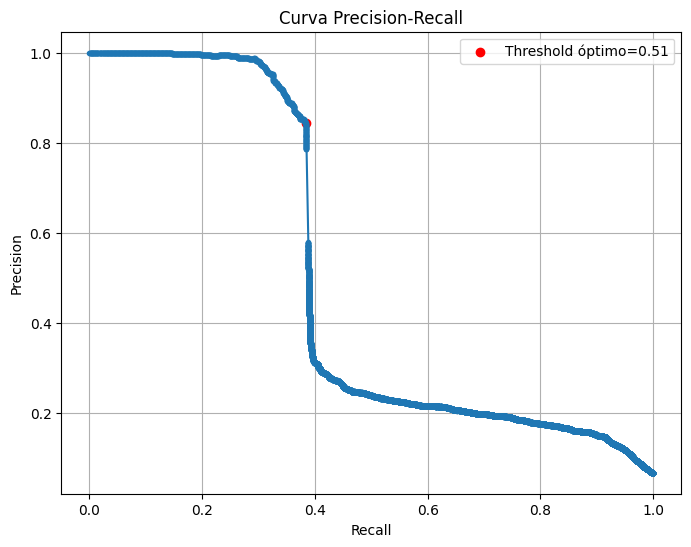

In [66]:
threshold_optimo, resultados = find_optimal_thres(y, y_proba, objetivo="f1", plot=True)

In [67]:
y_pred_thresh = (y_proba >= threshold_optimo).astype(int)

Primeramente pintaremos la curva ROC junto con su valor de AUC

In [68]:
from sklearn.metrics import roc_auc_score
from tqdm import tqdm


def compute_individual_auc(df, y, target_col):
    """
    Computes the individual ROC AUC of each feature against the target.
    
    Parameters
    ----------
    df : pd.DataFrame
        DataFrame containing features and target
    target_col : str
        Name of the target column (binary: 0/1)
    
    Returns
    -------
    auc_df : pd.DataFrame
        DataFrame with feature name and corresponding AUC score
    """

    auc_list = []
    features = [col for col in df.columns if col not in [target_col]]

    for col in tqdm(features, desc="Computing AUCs"):
        if df[col].nunique() > 1:  # avoid constant columns
            auc = roc_auc_score(y, df[col])
            auc_list.append((col, auc))

    auc_df = pd.DataFrame(auc_list, columns=["feature", "auc"]).sort_values("auc", ascending=False).reset_index(drop=True)
    return auc_df

In [69]:
auc_df = compute_individual_auc(X, y, target_col="target")

print(auc_df.head(30))

Computing AUCs: 100%|██████████| 70/70 [00:00<00:00, 227.81it/s]

                                              feature       auc
0                            consumo_zero_anio_actual  0.780372
1                          consumo_zero_anio_anterior  0.761914
2                       consumo_zero_trimestre_actual  0.713066
3                       consumo_zero_trimestre_pasado  0.703110
4                  consumo_zero_trimestre_anio_pasado  0.696507
5                             consumo_zero_mes_actual  0.680852
6                             consumo_zero_mes_pasado  0.675136
7                        consumo_zero_mes_anio_pasado  0.666634
8                          consumo_zero_semana_actual  0.663084
9                          consumo_zero_semana_pasada  0.659765
10                    consumo_zero_semana_anio_pasado  0.648866
11  porcentaje_calidad_datos_trimestre_pasado_corr...  0.621339
12   porcentaje_calidad_datos_semana_pasada_correctos  0.605589
13      porcentaje_calidad_datos_mes_pasado_correctos  0.604507
14   porcentaje_calidad_datos_anio_anter

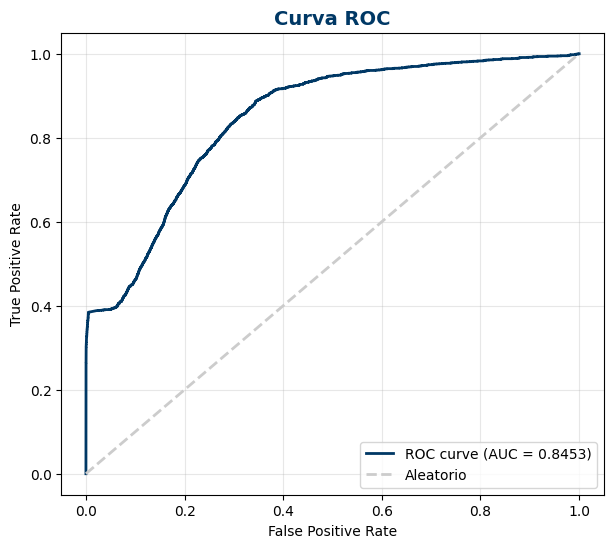

ROC AUC Score: 0.8453


In [70]:
fpr, tpr, thresholds = roc_curve(y, y_proba)
roc_auc = roc_auc_score(y, y_proba)

plt.figure(figsize=(7,6))
plt.plot(fpr, tpr, color=ufd_blue, lw=2, label=f"ROC curve (AUC = {roc_auc:.4f})")
plt.plot([0, 1], [0, 1], color=ufd_gray, lw=2, linestyle="--", label="Aleatorio")

# Estilo
plt.grid(alpha=0.3)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Curva ROC", fontsize=14, weight="bold", color=ufd_blue)
plt.legend(loc="lower right", fontsize=10)
plt.show()

print(f"ROC AUC Score: {roc_auc:.4f}")

In [71]:
final_df[top_100_features].corr()

,consumo_zero_anio_actual,consumo_zero_anio_anterior,consumo_zero_trimestre_actual,consumo_zero_trimestre_pasado,consumo_zero_mes_pasado,porcentaje_calidad_datos_trimestre_actual_correctos,consumo_zero_mes_anio_pasado,porcentaje_calidad_datos_semana_actual_correctos,consumo_min_anio_actual,porcentaje_calidad_datos_mes_actual_correctos,...,consumo_max_trimestre_anio_pasado,consumo_suma_semana_actual,consumo_media_semana_anio_pasado,consumo_suma_trimestre_pasado,consumo_stddev_trimestre_actual,consumo_media_semana_actual,consumo_min_mes_pasado,consumo_max_trimestre_actual,consumo_min_semana_anio_pasado,consumo_stddev_semana_actual
consumo_zero_anio_actual,1.000000,0.886468,0.955843,0.980359,0.945241,0.038217,0.923501,-0.091235,-0.021357,-0.003782,...,-0.049749,-0.034385,-0.038098,-0.030149,-0.042604,-0.037865,-0.024830,-0.053384,-0.026137,-0.043731
consumo_zero_anio_anterior,0.886468,1.000000,0.813821,0.846527,0.800834,0.029445,0.919274,-0.088519,-0.020061,-0.008407,...,-0.050052,-0.032000,-0.036451,-0.026473,-0.038334,-0.034542,-0.022345,-0.048228,-0.024851,-0.039960
consumo_zero_trimestre_actual,0.955843,0.813821,1.000000,0.945618,0.992824,0.042687,0.840664,-0.087630,-0.021060,0.001129,...,-0.047185,-0.034679,-0.036245,-0.030202,-0.043582,-0.038993,-0.025377,-0.054249,-0.025111,-0.044845
consumo_zero_trimestre_pasado,0.980359,0.846527,0.945618,1.000000,0.933001,0.038155,0.877702,-0.088180,-0.020651,-0.003553,...,-0.048306,-0.033375,-0.036774,-0.030446,-0.042040,-0.036853,-0.024090,-0.052688,-0.025056,-0.042438
consumo_zero_mes_pasado,0.945241,0.800834,0.992824,0.933001,1.000000,0.043785,0.829496,-0.086352,-0.020780,0.001642,...,-0.046521,-0.034191,-0.035897,-0.029690,-0.043040,-0.038511,-0.025308,-0.053446,-0.024964,-0.044274
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
consumo_media_semana_actual,-0.037865,-0.034542,-0.038993,-0.036853,-0.038511,0.030679,-0.034654,-0.004245,0.624811,0.016202,...,0.819096,0.951219,0.898643,0.944134,0.812954,1.000000,0.741643,0.838545,0.677782,0.831438
consumo_min_mes_pasado,-0.024830,-0.022345,-0.025377,-0.024090,-0.025308,0.033240,-0.022515,0.013007,0.854212,0.025180,...,0.508482,0.726848,0.694788,0.704494,0.419203,0.741643,1.000000,0.517612,0.885484,0.419248
consumo_max_trimestre_actual,-0.053384,-0.048228,-0.054249,-0.052688,-0.053446,0.091463,-0.048514,0.036170,0.457029,0.073259,...,0.958682,0.809518,0.769181,0.864302,0.962743,0.838545,0.517612,1.000000,0.493210,0.925817
consumo_min_semana_anio_pasado,-0.026137,-0.024851,-0.025111,-0.025056,-0.024964,0.021131,-0.025587,0.005820,0.861101,0.014890,...,0.534674,0.669870,0.754883,0.665328,0.396330,0.677782,0.885484,0.493210,1.000000,0.399503


Mostramos también las curvas de ganancia y lift a continuación

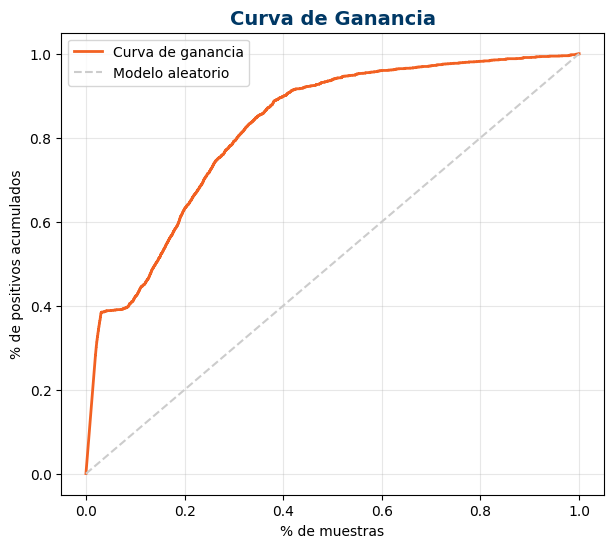

In [72]:
plot_gain(y, y_proba)

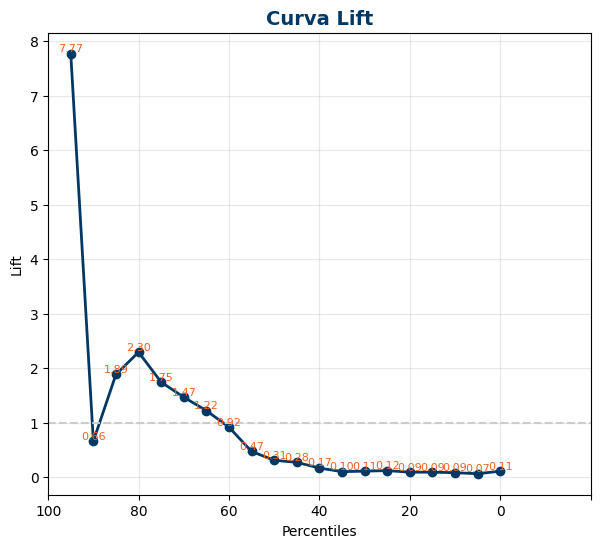

In [73]:
plot_lift(y, y_proba, bins=20)

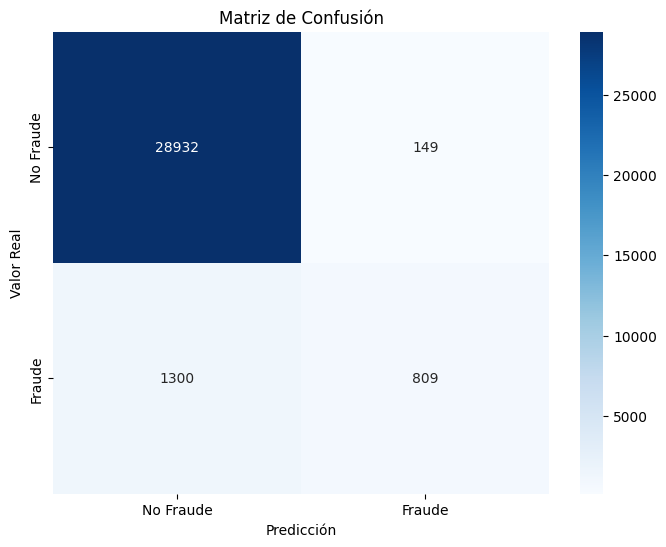


Reporte de Clasificación:
              precision    recall  f1-score   support

         0.0       0.96      0.99      0.98     29081
         1.0       0.84      0.38      0.53      2109

    accuracy                           0.95     31190
   macro avg       0.90      0.69      0.75     31190
weighted avg       0.95      0.95      0.95     31190



In [74]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
cm = confusion_matrix(y, y_pred_thresh)

# Crear una visualización más clara
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['No Fraude', 'Fraude'], 
            yticklabels=['No Fraude', 'Fraude'])
plt.title('Matriz de Confusión')
plt.xlabel('Predicción')
plt.ylabel('Valor Real')
plt.show()

# También puedes mostrar el reporte de clasificación completo
print("\nReporte de Clasificación:")
print(classification_report(y, y_pred_thresh))

In [75]:
final_df["target"].value_counts()

target
0.0    29081
1.0     2109
Name: count, dtype: int64

In [76]:
# # First, get the indices of the test set in final_df
# test_indices = X_test.index
# train_indices = X_train.index

# # Assign the predicted probabilities to the correct rows
# final_df.loc[test_indices, "xgb_pred_proba"] = y_proba
# final_df.loc[train_indices, "xgb_pred_proba"] = y_proba_train

# final_df.loc[test_indices, "train"] = 0
# final_df.loc[train_indices, "train"] = 1

In [77]:
# final_df["final_scoring"] = final_df["fraude_score_no_supervisado"]*0.3 + final_df["xgb_pred_proba"]*0.7

We define the cuts attending to the lift chart previously defined:

In [78]:
# cuts = [25, 35]  
# thresholds = get_probability_thresholds(y_test, y_proba, cuts)

# print("Thresholds:", thresholds)

We create the new cateogria_fraude column used to order the probabilistic results of the fraud

In [79]:
# conditions = [
#     final_df["final_scoring"] < thresholds[0],                             
#     (final_df["final_scoring"] >= thresholds[0]) & (final_df["final_scoring"] < thresholds[1]),  
#     final_df["final_scoring"] >= thresholds[1]                             
# ]

# choices = ["Bajo", "Medio", "Alto"]

# final_df["categoria_fraude"] = np.select(conditions, choices, default="Bajo")

### 5.4.3. Feature importance

In [80]:
# importance_dict = model.get_booster().get_score(importance_type='gain')

# importance_df = pd.DataFrame({
#     'feature': list(importance_dict.keys()),
#     'importance': [round(value, 3) for value in importance_dict.values()]
# }).sort_values(by='importance', ascending=False)

We make a fast plot in order to visualize the importance

In [81]:
# plt.figure(figsize=(10, 8))
# plot_importance(model, importance_type='gain', max_num_features=20, height=0.5, grid=True)
# plt.title("XGBoost Feature Importance (gain)")
# plt.show()

In [82]:
final_df["target"] = final_df["target"].astype(int)
final_df.head(10)

,cups_sgc,cnt_id,cnt_inspecciones_semana_actual,cnt_inspecciones_semana_pasada,cnt_inspecciones_misma_semana_anio_pasado,cnt_inspecciones_mes_actual,cnt_inspecciones_mes_pasado,cnt_inspecciones_mismo_mes_anio_pasado,cnt_inspecciones_trimestre_actual,cnt_inspecciones_trimestre_pasado,...,porcentaje_calidad_datos_anio_actual_correctos,porcentaje_calidad_datos_anio_actual_incorrectos,porcentaje_calidad_datos_anio_anterior_correctos,porcentaje_calidad_datos_anio_anterior_incorrectos,target,anomaly_dbscan,anomaly_iso,reconstruction_error,anomaly_autoencoder,fraude_score_no_supervisado_norm
0,ES0022000001000008QR1P,SAG0185769835,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,97.52,0.00,99.44,0.00,1,True,False,0.136588,False,0.333333
1,ES0022000001001149LS1P,SAG0185746454,0.0,0.0,0.0,0.0,28.0,0.0,28.0,0.0,...,95.81,0.03,75.35,0.01,0,False,False,0.012145,False,0.000000
2,ES0022000001001381YV1P,SAG0186400186,0.0,0.0,0.0,0.0,0.0,27.0,0.0,0.0,...,98.46,0.16,83.86,0.27,0,False,False,0.034933,False,0.000000
3,ES0022000001001663LT1P,ZIV0036507981,0.0,0.0,0.0,0.0,0.0,31.0,0.0,54.0,...,19.97,0.02,0.00,0.00,0,False,False,0.105869,False,0.000000
4,ES0022000001002279EH1P,ZIV0047987967,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,99.71,0.00,101.61,0.02,0,True,False,1.762964,True,0.333333
5,ES0022000001002372AL1P,SAG0185734056,0.0,0.0,0.0,0.0,29.0,0.0,29.0,0.0,...,91.50,0.02,99.72,0.00,0,False,False,0.026714,False,0.000000
6,ES0022000001005251ZT1P,SAG0185729235,0.0,0.0,0.0,0.0,0.0,0.0,0.0,26.0,...,98.21,0.09,94.80,0.00,0,False,False,0.015650,False,0.000000
7,ES0022000001005425KJ1P,SAG0185748781,0.0,0.0,0.0,0.0,0.0,0.0,0.0,28.0,...,98.06,0.00,99.70,0.00,0,False,False,0.004148,False,0.000000
8,ES0022000001006539RT1P,ZIV0050276191,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,1.53,0.03,0.00,0.00,0,False,False,0.171999,False,0.000000
9,ES0022000001007458VE1P,SAG0185748789,0.0,0.0,0.0,0.0,0.0,0.0,29.0,26.0,...,97.15,0.00,98.35,0.00,0,False,False,0.044675,False,0.000000


In [83]:
# First, get the indices of the test set in final_df
indices = X.index

# Assign the predicted probabilities to the correct rows
final_df.loc[indices, "logreg_prediction"] = y_pred_thresh
final_df.loc[indices, "logreg_pred_proba"] = y_proba

In [84]:
final_df["final_scoring"] = final_df["fraude_score_no_supervisado_norm"]*0.3 + final_df["logreg_pred_proba"]*0.7

## 5.5. Evaluating the model

We are going to use the previously trained model to test it in the april data for example. Thus, let's go for it

In [85]:
for col in X:
    if col not in X_eval:
        X_eval[col] = 0

In [86]:
y_proba_eval = model.predict_proba(X_eval[X.columns])[:, 1] 
# y_pred_eval = model.predict(X_eval[X.columns])

# y_pred_eval_thresh, y_proba_eval_thresh = predict_with_threshold(model, X_eval[X.columns], 0.05)

In [87]:
y_pred_eval_thresh = (y_proba_eval >= threshold_optimo).astype(int)

Primeramente pintaremos la curva ROC junto con su valor de AUC

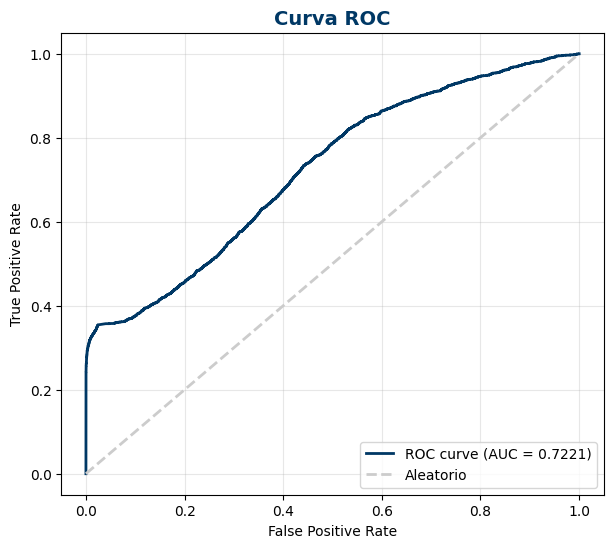

ROC AUC Score: 0.7221


In [88]:
fpr, tpr, thresholds = roc_curve(y_eval, y_proba_eval)
roc_auc_eval = roc_auc_score(y_eval, y_proba_eval)

plt.figure(figsize=(7,6))
plt.plot(fpr, tpr, color=ufd_blue, lw=2, label=f"ROC curve (AUC = {roc_auc_eval:.4f})")
plt.plot([0, 1], [0, 1], color=ufd_gray, lw=2, linestyle="--", label="Aleatorio")

# Estilo
plt.grid(alpha=0.3)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Curva ROC", fontsize=14, weight="bold", color=ufd_blue)
plt.legend(loc="lower right", fontsize=10)
plt.show()

print(f"ROC AUC Score: {roc_auc_eval:.4f}")

Mostramos también las curvas de ganancia y lift a continuación

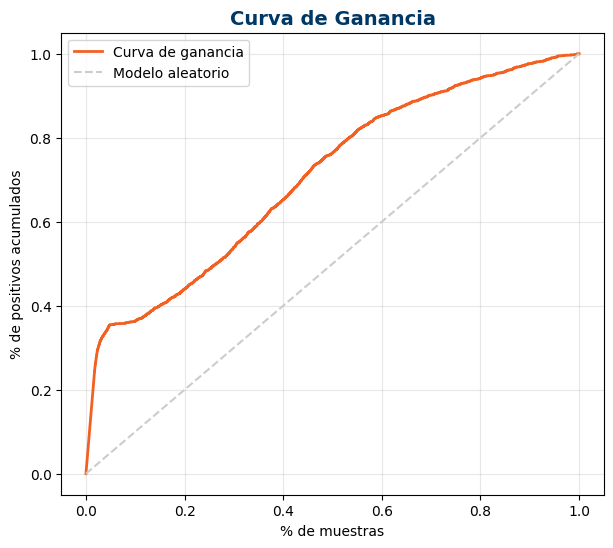

In [89]:
plot_gain(y_eval, y_proba_eval)

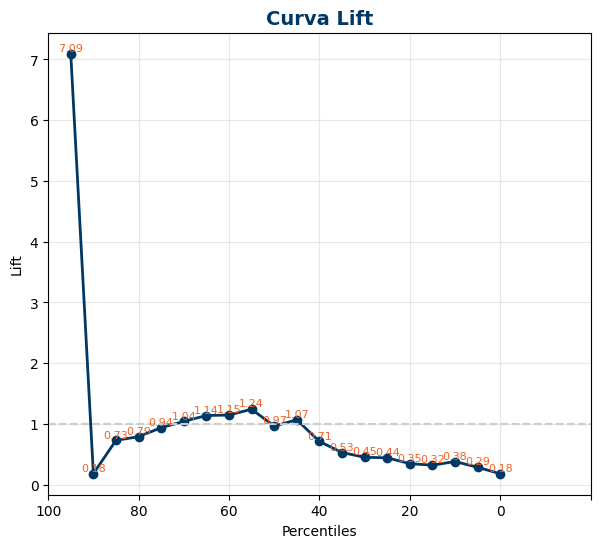

In [90]:
plot_lift(y_eval, y_proba_eval, bins=20)

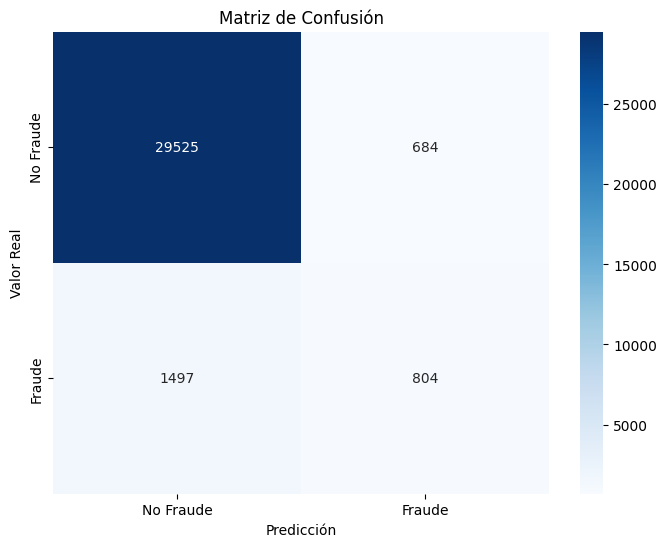


Reporte de Clasificación:
              precision    recall  f1-score   support

         0.0       0.95      0.98      0.96     30209
         1.0       0.54      0.35      0.42      2301

    accuracy                           0.93     32510
   macro avg       0.75      0.66      0.69     32510
weighted avg       0.92      0.93      0.93     32510



In [91]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
cm = confusion_matrix(y_eval, y_pred_eval_thresh)

# Crear una visualización más clara
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['No Fraude', 'Fraude'], 
            yticklabels=['No Fraude', 'Fraude'])
plt.title('Matriz de Confusión')
plt.xlabel('Predicción')
plt.ylabel('Valor Real')
plt.show()

# También puedes mostrar el reporte de clasificación completo
print("\nReporte de Clasificación:")
print(classification_report(y_eval, y_pred_eval_thresh))

In [92]:
# First, get the indices of the test set in final_df
indices_eval = X_eval.index

# Assign the predicted probabilities to the correct rows
final_df_eval.loc[indices_eval, "logreg_prediction"] = y_pred_eval_thresh
final_df_eval.loc[indices_eval, "logreg_pred_proba"] = y_proba_eval

In [93]:
final_df_eval["final_scoring"] = final_df_eval["fraude_score_no_supervisado_norm"]*0.3 + final_df_eval["logreg_pred_proba"]*0.7

In [94]:
final_df_eval.sort_values("final_scoring", ascending=False)

,cups_sgc,cnt_id,cnt_inspecciones_semana_actual,cnt_inspecciones_semana_pasada,cnt_inspecciones_misma_semana_anio_pasado,cnt_inspecciones_mes_actual,cnt_inspecciones_mes_pasado,cnt_inspecciones_mismo_mes_anio_pasado,cnt_inspecciones_trimestre_actual,cnt_inspecciones_trimestre_pasado,...,porcentaje_calidad_datos_anio_anterior_incorrectos,target,anomaly_dbscan,anomaly_iso,reconstruction_error,anomaly_autoencoder,fraude_score_no_supervisado_norm,logreg_prediction,logreg_pred_proba,final_scoring
9940,ES0022000005718635JV1P,ZIV0040175250,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.00,1.0,True,False,0.078287,False,0.333333,1.0,1.000000,0.800000
16603,ES0022000006716497KR1P,ZIV0048387377,0.0,0.0,0.0,0.0,0.0,0.0,0.0,27.0,...,0.03,1.0,True,False,0.116870,False,0.333333,1.0,1.000000,0.800000
28181,ES0022000008627365AY1P,ZIV0048650273,0.0,0.0,0.0,0.0,0.0,0.0,0.0,28.0,...,0.03,1.0,True,False,0.604360,True,0.333333,1.0,1.000000,0.800000
8324,ES0022000005574635PC1P,SOG0940093482,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.00,1.0,True,False,0.334607,True,0.333333,1.0,1.000000,0.800000
10864,ES0022000006075130BN1P,ZIV0042717209,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.01,1.0,True,False,12.114931,True,0.333333,1.0,1.000000,0.800000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7867,ES0022000005532215GN1P,SAG0115272462,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.00,0.0,False,False,0.017782,False,0.000000,0.0,0.001859,0.001301
20601,ES0022000007579475ML1P,LGZ0012134711,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.00,0.0,False,False,0.016611,False,0.000000,0.0,0.001607,0.001125
27449,ES0022000008556722JL1P,ZIV0047986372,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.00,0.0,False,False,0.016240,False,0.000000,0.0,0.001481,0.001037
10467,ES0022000006023136GK1P,SAG0165508020,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.00,0.0,False,False,0.016007,False,0.000000,0.0,0.000570,0.000399


## 5.6. Dashboard data extraction

Necesitamos extraer ciertos ficheros para la construcción del dashboard en powerbi

In [95]:
columnas_considerar_preds = ["cups_sgc", "cnt_id", "fraude_score_no_supervisado", 
                             "xgb_pred_proba", "final_scoring", "categoria_fraude", "target", "train"]

In [96]:
# final_df[columnas_considerar_preds].to_csv("powerbi/predicciones_cups.csv", index=False, sep=";", decimal=",")

In [97]:
# def lift_at_percentile(y_true, y_proba, percentile=0.1):
#     """
#     Calcula el Lift en el top X% (percentile en [0,1]).
#     """
#     n = int(len(y_proba) * percentile)
#     # Ordenar por probabilidad descendente
#     idx = np.argsort(y_proba)[::-1]
#     y_sorted = np.array(y_true)[idx]
    
#     # Positivos en el top %
#     top_positives = y_sorted[:n].sum()
#     total_positives = y_sorted.sum()
    
#     perc_total = top_positives / total_positives
#     perc_samples = n / len(y_true)
    
#     lift = perc_total / perc_samples
#     return lift, perc_total

# def compute_metrics(y_true, y_proba, dataset_name="test"):
#     auc = roc_auc_score(y_true, y_proba)
#     gini = 2 * auc - 1
#     ks = ks_stat(y_true, y_proba)
#     lift10, capture10 = lift_at_percentile(y_true, y_proba, 0.1)
#     lift20, capture20 = lift_at_percentile(y_true, y_proba, 0.2)

#     return {
#         "dataset": dataset_name,
#         "auc": round(auc, 3),
#         "gini": round(gini, 3),
#         "ks": round(ks, 3),
#         "lift_at_10": lift10,
#         "capture_rate_10": capture10,
#         "lift_at_20": lift20,
#         "capture_rate_20": capture20
#     }

# # =====================
# # Calcular métricas train y test
# # =====================
# metrics_train = compute_metrics(y_train, y_proba_train, dataset_name="train")
# metrics_test = compute_metrics(y_test, y_proba, dataset_name="test")

# model_metrics = pd.DataFrame([metrics_train, metrics_test])
# model_metrics.to_csv("powerbi/model_metrics.csv", index=False, sep=";", decimal=",")

In [98]:
# fpr, tpr, thresholds = roc_curve(y_test, y_proba)

# roc_data = pd.DataFrame({
#     "fpr": fpr,
#     "tpr": tpr,
#     "threshold": thresholds
# })
# roc_data.to_csv("powerbi/roc_curve.csv", index=False, sep=";", decimal=",")

In [99]:
# data = list(zip(y_test, y_proba))
# data = sorted(data, key=lambda x: x[1], reverse=True)
# y_sorted = np.array([d[0] for d in data])

# cum_gains = np.cumsum(y_sorted) / sum(y_sorted)
# perc_samples = np.arange(1, len(y_sorted)+1) / len(y_sorted)

# gain_data = pd.DataFrame({
#     "perc_samples": perc_samples,
#     "cum_gains": cum_gains
# })
# gain_data.to_csv("powerbi/gain_curve.csv", index=False, sep=";", decimal=",")

In [100]:
# def compute_lift(y_true, y_proba, bins=20):
#     data = list(zip(y_true, y_proba))
#     data = sorted(data, key=lambda x: x[1], reverse=True)
#     y_sorted = np.array([d[0] for d in data])

#     total_rate = sum(y_sorted) / len(y_sorted)
#     group_size = len(y_sorted) // bins
#     lift_values, percentiles = [], []

#     for i in range(bins):
#         start = i * group_size
#         end = (i+1) * group_size if i < bins-1 else len(y_sorted)
#         group = y_sorted[start:end]
#         group_rate = sum(group) / len(group)
#         lift = group_rate / total_rate
#         lift_values.append(lift)
#         percentiles.append(100 - (i+1)*(100//bins))  # de 100 a 0

#     return pd.DataFrame({
#         "percentil": percentiles,
#         "lift": lift_values
#     })

# lift_data = compute_lift(y_test, y_proba, bins=20)
# lift_data.to_csv("powerbi/lift_curve.csv", index=False, sep=";", decimal=",")

In [101]:
# 'dataset' contiene los datos de entrada para este script
# import pandas as pd
# from pyproj import Transformer

# # dataset = tabla que llega desde Power BI
# df = pd.read_csv("coordenadas_contadores.csv")

# # Convertir a numérico (si hay valores raros, los pone como NaN)
# df["coord_utm_x_bdi"] = pd.to_numeric(df["coord_utm_x_bdi"], errors="coerce")
# df["coord_utm_y_bdi"] = pd.to_numeric(df["coord_utm_y_bdi"], errors="coerce")

# # Crear transformador (UTM zona 30N -> WGS84)
# transformer = Transformer.from_crs("EPSG:25830", "EPSG:4326", always_xy=True)

# # Transformar coordenadas (saltará NaN si alguna fila no tenía valores válidos)
# df["longitud"], df["latitud"] = transformer.transform(
#     df["coord_utm_x_bdi"].values,
#     df["coord_utm_y_bdi"].values
# )

# df.to_csv("coordenadas_contadores_lat_long.csv", index=False, decimal=",", sep=";")


In [102]:
# df.head(10)

In [103]:
# color1 = "#cccccc"
# color2 = "#003865"

In [104]:
# def lift_chart_plot(y_test, predict_proba_test, num_chunks = None, cuts = None, color1 = color1, color2 = color2):
#     """
#     Generates the lift chart with the standard visualization.
    
#     Parameters:
#         - y_test: `DataFrame`. Object with data regarding the target variable. It corresponds to the dataset left aside for the testing phase.
#         - predict_proba_test: `list` of `float`. Object with the predicted probabilites for the given model to study.
#         - num_chunks: `int`. Number of equivalent groups into which the gain porportion will be studies (2: for 50% and 100%)
#         - cuts: `list` of `float`. Specific decimal amount of register for which to calculate gain proportion (values from 0 to 1)
#         - color1: `str`. Color code for plot representation.
#         - color2: `str`. Color code for plot representation.

#     Returns: 
#         Plot of lift chart.
#     """    
#     values = sorted([(true, proba) for true, proba in zip(y_test, predict_proba_test)], key=lambda x: -x[1])
#     sorted_labels = [x[0] for x in values]
    
#     num_points = len(sorted_labels)
#     percent_1s = sum(sorted_labels)/num_points
    
#     if num_chunks is not None:
#         percent_chunks = [ i/num_chunks for i in range(1, num_chunks+1)]
        
#     if cuts is not None:
#         percent_chunks = cuts
    
#     index_chunks = [0]+[round(num_points*perc) for perc in percent_chunks]
    
#     y_values = [round((sum(sorted_labels[index_chunks[index]:index_chunks[index+1]])/
#                        len(sorted_labels[index_chunks[index]:index_chunks[index+1]]))/percent_1s, 2)
#                 for index in range(len(index_chunks)-1)]
#     x_values = [round(percent*100,2) for percent in percent_chunks]
    
#     plt.plot(x_values, y_values, marker='o', color = color2)
#     plt.plot([0,100], [1,1], color=color1)
#     plt.xlabel('Porcentaje de contadores', fontsize=14, weight='bold')
#     plt.xticks(x_values)
#     plt.xlim([x_values[0], x_values[-1]])
#     plt.ylabel('Valor LIFT', fontsize=14, weight='bold')
#     plt.title('Curva LIFT', fontsize=18, weight='bold')
#     for x, y in zip(x_values, y_values):
#         plt.annotate(f'{y}', (x,y), (x, y+0.07))
#     plt.show()

In [105]:
# lift_chart_plot(y_test, y_proba, num_chunks=10, color1=color1, color2=color2)